In [29]:
import subprocess
import sys
import re
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import seaborn.objects as so
import warnings
warnings.filterwarnings("ignore")
import multiprocessing as mp

### Compile, set up and run the code

In [ ]:
controlEvoFile = "radiogenic_evo_models/evo-control.dat"

structFileName = "struct-dev.dat"
evolveFileName = "radiogenic_evo_models/evo-doublecheck.dat"
#runcmd = f"./PlanetSolver -cn 1 0.2925 -en 2 0.607495 -a 8.9 30 0.1 -s 1 1 1 0.3 -m 8.0 -evolve 1 -re 1000 -struct {structFileName} -wr {evolveFileName}"
runcmd = f"./PlanetSolver -cn 1 0.2925 -en 2 0.607495 -a 8.9 30 0.1 -s 1 1 1 0.3 -m 8.0 -evolve 1 -inject 1.417e31 1000 -struct {structFileName} -wr {evolveFileName}"


In [3]:
result = subprocess.run(
"make clean", 
shell=True, 
capture_output=True, 
text=True,
timeout=300
)
if result.returncode != 0:
    raise OSError("OS could not handle make clean")
print("Cleaned")

result = subprocess.run(
"make", 
shell=True, 
capture_output=True, 
text=True,
timeout=300
)
if result.returncode != 0:
    print(result.stdout)
    raise OSError(f"Could not make:{result.stderr}")
print("Made")

"""
result = subprocess.run(
runcmd, 
shell=True, 
capture_output=True, 
text=True,
timeout=300
)
if result.returncode != 0:
    print(result.stdout)
    raise OSError("Runtime error")
print("Executed with exit code 0")
print(result.stdout)
"""


Cleaned
Made


'\nresult = subprocess.run(\nruncmd, \nshell=True, \ncapture_output=True, \ntext=True,\ntimeout=300\n)\nif result.returncode != 0:\n    print(result.stdout)\n    raise OSError("Runtime error")\nprint("Executed with exit code 0")\nprint(result.stdout)\n'

In [4]:
#multiprocessing

def run_sims(mag):
    magstr = str(mag).replace(".","-")
    factor = 10**mag
    runcmd = f"./PlanetSolver -cn 1 0.2925 -en 2 0.607495 -a 8.9 30 0.1 -s 1 1 1 0.3 -m 8.0 -evolve 1 -re {factor} -struct {structFileName} -wr {evolveFileName}-{magstr}"
    print(runcmd)
    result = subprocess.run(
    runcmd, 
    shell=True, 
    capture_output=True, 
    text=True,
    timeout=500
    )
if result.returncode != 0:
    print(result.stdout)
    raise OSError("Runtime error")
print("Executed with exit code 0")
print(result.stdout)
re_factors = [0, 1, 1.5, 1.75, 2, 2.25, 2.5, 2.75, 3, 3.25]
with mp.Pool(processes=mp.cpu_count()-1) as pool:
    all_results = pool.map(run_sims, re_factors)

Executed with exit code 0
g++ -O3 src/PlanetSolver.cpp src/constants.cpp src/EOS.cpp src/Planet.cpp src/HHeComp.cpp -o PlanetSolver
g++ -O3 src/EqGen.cpp src/constants.cpp src/EOS.cpp src/HHeComp.cpp -o EqGen

./PlanetSolver -cn 1 0.2925 -en 2 0.607495 -a 8.9 30 0.1 -s 1 1 1 0.3 -m 8.0 -evolve 1 -re 1 -struct struct-dev.dat -wr evo-doublecheck.dat-0./PlanetSolver -cn 1 0.2925 -en 2 0.607495 -a 8.9 30 0.1 -s 1 1 1 0.3 -m 8.0 -evolve 1 -re 10 -struct struct-dev.dat -wr evo-doublecheck.dat-1./PlanetSolver -cn 1 0.2925 -en 2 0.607495 -a 8.9 30 0.1 -s 1 1 1 0.3 -m 8.0 -evolve 1 -re 31.622776601683793 -struct struct-dev.dat -wr evo-doublecheck.dat-1-5./PlanetSolver -cn 1 0.2925 -en 2 0.607495 -a 8.9 30 0.1 -s 1 1 1 0.3 -m 8.0 -evolve 1 -re 100 -struct struct-dev.dat -wr evo-doublecheck.dat-2./PlanetSolver -cn 1 0.2925 -en 2 0.607495 -a 8.9 30 0.1 -s 1 1 1 0.3 -m 8.0 -evolve 1 -re 56.23413251903491 -struct struct-dev.dat -wr evo-doublecheck.dat-1-75./PlanetSolver -cn 1 0.2925 -en 2 0.607495 -

### View the modeled evolution

In [33]:
from astropy import units as u
def __pl_density_cgs(radius, mass, rad_err = None, mass_err = None):
    """
    Calculate the bulk density of a planet in cgs units (g/cm³) with error propagation.

    Parameters
    ----------
    radius : float or `~astropy.units.Quantity`
        Planetary radius. If a float is provided, it is assumed to be in Earth radii.
        If a `Quantity` is provided, it must be compatible with length units.

    mass : float or `~astropy.units.Quantity`
        Planetary mass. If a float is provided, it is assumed to be in Earth masses.
        If a `Quantity` is provided, it must be compatible with mass units.

    rad_err : float, array-like, `~astropy.units.Quantity`, or None, optional
        Uncertainty in planetary radius. If a float is provided, it is assumed to be
        in the same units as radius. If array-like of length 2, treated as
        asymmetric errors [lower, upper] and averaged for symmetric approximation.
        If None, no error propagation is performed.

    mass_err : float, array-like, `~astropy.units.Quantity`, or None, optional
        Uncertainty in planetary mass. If a float is provided, it is assumed to be
        in the same units as mass. If array-like of length 2, treated as
        asymmetric errors [lower, upper] and averaged for symmetric approximation.
        If None, no error propagation is performed.

    Returns
    -------
    density : `~astropy.units.Quantity`
        Planetary bulk density in grams per cubic centimeter (g/cm³).

    density_err : `~astropy.units.Quantity`, array, or None
        Uncertainty in planetary bulk density in g/cm³. Returns None if neither
        rad_err nor mass_err is provided. If input errors are asymmetric (length-2 arrays),
        returns asymmetric errors as array [lower_error, upper_error]. Otherwise returns
        symmetric error as scalar Quantity.

    Notes
    -----
    - If both inputs are floats, the function assumes they are in Earth units.
    - Automatically converts units to CGS (centimeters and grams) before computing.
    - Volume is computed assuming a spherical planet.
    - Error propagation uses standard uncertainty propagation formulas for
        density = mass / ((4/3) * π * radius³). For asymmetric input errors,
        the method properly propagates them to asymmetric density errors by
        considering the sign of partial derivatives.
    """
    #----Unit handling-----#
    # Handle radius units
    if not isinstance(radius, u.Quantity):
        radius = radius * u.R_earth  # assume in Earth radii

    # Handle mass units
    if not isinstance(mass, u.Quantity):
        mass = mass * u.M_earth  # assume in Earth masses

    # Handle radius error units
    if rad_err is not None:
        if not isinstance(rad_err, u.Quantity):
            # Assume same units as radius before conversion
            if not isinstance(radius, u.Quantity):
                rad_err = rad_err * u.R_earth
            else:
                rad_err = rad_err * radius.unit

    # Handle mass error units
    if mass_err is not None:
        if not isinstance(mass_err, u.Quantity):
            # Assume same units as mass before conversion
            if not isinstance(mass, u.Quantity):
                mass_err = mass_err * u.M_earth
            else:
                mass_err = mass_err * mass.unit

    # Convert to cgs
    radius_cgs = radius.to(u.cm)
    mass_cgs = mass.to(u.g)
    mass_err_cgs = None
    rad_err_cgs = None
    if rad_err is not None:
        rad_err_cgs = rad_err.to(u.cm)
    if mass_err is not None:
        mass_err_cgs = mass_err.to(u.g)

    # Calculate density
    V = (4 / 3) * np.pi * radius_cgs ** 3
    density = mass_cgs / V

    # Calculate error if requested
    density_err = None
    if rad_err is not None or mass_err is not None:
        # Partial derivatives for error propagation
        # ρ = M / ((4/3)πR³)
        # ∂ρ/∂M = 1 / ((4/3)πR³) = ρ/M
        # ∂ρ/∂R = -3M / ((4/3)πR⁴) = -3ρ/R

        # Check if we have asymmetric errors
        mass_is_asymmetric = mass_err is not None and hasattr(mass_err_cgs, '__len__') and len(mass_err_cgs) == 2
        rad_is_asymmetric = rad_err is not None and hasattr(rad_err_cgs, '__len__') and len(rad_err_cgs) == 2

        if mass_is_asymmetric or rad_is_asymmetric:
            # Handle asymmetric error propagation
            dρ_dM = density / mass_cgs if mass_err is not None else 0
            dρ_dR = -3 * density / radius_cgs if rad_err is not None else 0

            # Calculate lower and upper bounds
            err_lower_terms = []
            err_upper_terms = []

            if mass_err is not None:
                if mass_is_asymmetric:
                    # For mass: positive derivative, so lower mass error -> lower density error
                    err_lower_terms.append((dρ_dM * mass_err_cgs[0]) ** 2)
                    err_upper_terms.append((dρ_dM * mass_err_cgs[1]) ** 2)
                else:
                    # Symmetric mass error
                    mass_term = (dρ_dM * mass_err_cgs) ** 2
                    err_lower_terms.append(mass_term)
                    err_upper_terms.append(mass_term)

            if rad_err is not None:
                if rad_is_asymmetric:
                    # For radius: negative derivative, so lower radius error -> upper density error
                    err_lower_terms.append((dρ_dR * rad_err_cgs[1]) ** 2)  # Note: switched indices
                    err_upper_terms.append((dρ_dR * rad_err_cgs[0]) ** 2)  # Note: switched indices
                else:
                    # Symmetric radius error
                    rad_term = (dρ_dR * rad_err_cgs) ** 2
                    err_lower_terms.append(rad_term)
                    err_upper_terms.append(rad_term)

            density_err_lower = np.sqrt(sum(err_lower_terms))
            density_err_upper = np.sqrt(sum(err_upper_terms))

            # Return as array [lower, upper] with proper units
            density_err = np.array([density_err_lower.value, density_err_upper.value]) * density.unit

        else:
            # Handle symmetric error propagation
            err_terms = []

            if mass_err is not None:
                dρ_dM = density / mass_cgs
                err_terms.append((dρ_dM * mass_err_cgs) ** 2)

            if rad_err is not None:
                dρ_dR = -3 * density / radius_cgs
                err_terms.append((dρ_dR * rad_err_cgs) ** 2)

            if err_terms:
                density_err = np.sqrt(sum(err_terms))

    if density_err is None:
        return density
    else:
        return density, density_err
    

In [54]:
input_col_names = ['Age', 'Atmospheric Entropy', 'Radius', 'Mass', 'delta_M', 'AMF', 'T_eff', "Density"]
evodfs = {}
evodfs2 = {}
for factor in re_factors:
    if factor == 0: 
         continue #this was only added to make sure the test set was consistent with control
    factor_filename = str(factor).replace(".","-")
    efile = evolveFileName + f"-{factor_filename}"
    with open(efile, 'r') as file:
            lines = file.readlines()
    data_start_idx = None
    header_lines = []
        
    for i, line in enumerate(lines):
        line = line.strip()
        # Look for the column headers
        if 'Age (Myr)' in line and 'Entropy' in line and 'Radius' in line:
            data_start_idx = i+1 #skips heading column
            break
        else:
            header_lines.append(line)

    evodf = pd.read_table(efile, skiprows=data_start_idx, names=input_col_names, sep=" ")
   
    for i in range(0, len(evodf)):
         density = __pl_density_cgs(radius=evodf["Radius"][i], mass=evodf["Mass"][i])
         evodf.at[i, "Density"] = density.value
    
    if len(evodf) > 180:
        evodfs[factor_filename] = evodf
    else:
        evodfs2[factor_filename] = evodf


for factor in re_factors:
    if factor == 0: 
         continue #this was only added to make sure the test set was consistent with control
    factor_filename = str(factor).replace(".","-")
    efile = "evo-dev.dat" + f"-{factor_filename}"
    with open(efile, 'r') as file:
            lines = file.readlines()
    data_start_idx = None
    header_lines = []
        
    for i, line in enumerate(lines):
        line = line.strip()
        # Look for the column headers
        if 'Age (Myr)' in line and 'Entropy' in line and 'Radius' in line:
            data_start_idx = i+1 #skips heading column
            break
        else:
            header_lines.append(line)

    evodf = pd.read_table(efile, skiprows=data_start_idx, names=input_col_names, sep=" ")
    
    for i in range(0, len(evodf)):
         density = __pl_density_cgs(radius=evodf["Radius"][i], mass=evodf["Mass"][i])
         evodf.at[i, "Density"] = density.value
    

    if len(evodf) > 180:
        evodfs[factor_filename] = evodf
    else:
        evodfs2[factor_filename] = evodf

# Get control file
with open(controlEvoFile, 'r') as file:
        lines = file.readlines()
data_start_idx = None
header_lines = []
    
for i, line in enumerate(lines):
    line = line.strip()
    # Look for the column headers
    if 'Age (Myr)' in line and 'Entropy' in line and 'Radius' in line:
        data_start_idx = i+1 #skips heading column
        break
    else:
        header_lines.append(line)

dfcontrol = pd.read_table(controlEvoFile, skiprows=data_start_idx, names=input_col_names, sep=" ")
for i in range(0, len(dfcontrol)):
         density = __pl_density_cgs(radius=dfcontrol["Radius"][i], mass=dfcontrol["Mass"][i])
         dfcontrol.at[i, "Density"] = density.value

#Delete later
evodfs2["3-251"] = pd.read_table("evo-doublecheck.dat-3-250", skiprows=6, names=input_col_names, sep=" ")

In [55]:
evodfs['1-5']

,Age,Atmospheric Entropy,Radius,Mass,delta_M,AMF,T_eff,Density
0,0.000000,8.40000,9.41637,8.00012,0.000000,0.100000,0.0000,0.052652
1,0.095541,8.39000,5.48765,8.00004,0.000074,0.099992,368.5350,0.266013
2,0.384524,8.38000,5.44776,8.00000,0.000048,0.099986,365.8620,0.271898
3,0.685384,8.37000,5.40857,7.99995,0.000049,0.099981,363.2100,0.277849
4,0.998590,8.36000,5.37015,7.99990,0.000049,0.099975,360.5700,0.283854
...,...,...,...,...,...,...,...,...
284,13673.800000,6.22591,2.75677,7.76341,0.000013,0.072558,73.7248,2.036200
285,13773.800000,6.22270,2.75549,7.76339,0.000013,0.072557,73.5286,2.039033
286,13873.800000,6.21952,2.75410,7.76338,0.000013,0.072555,73.3720,2.042120
287,13973.800000,6.21635,2.75277,7.76337,0.000013,0.072554,73.2153,2.045078


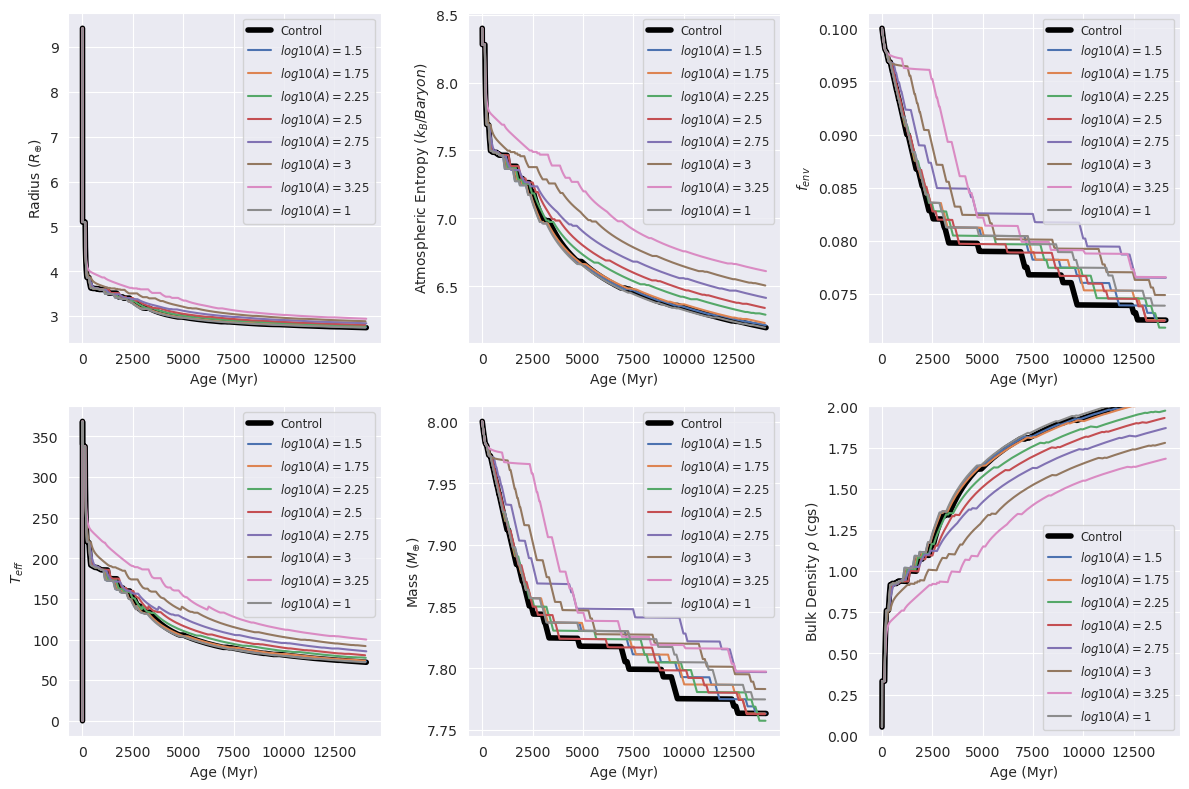

In [61]:
sns.set_theme({"axes.spines.left": True, "axes.spines.bottom": True, 
          "axes.spines.top": False, "axes.spines.right": False})
f, axes = plt.subplots(2, 3, figsize=(12, 8))
axs = axes.flatten()

sns.lineplot(data=dfcontrol, x="Age", y="Radius", ax=axs[0], color='black', label='Control', lw=4)
for key, df in evodfs.items():
    sns.lineplot(data=df, x='Age', y="Radius", ax=axs[0], label=rf'$log10(A)=${key.replace("-", ".")}')
axs[0].legend(fontsize='small')
axs[0].set_ylabel(r"Radius ($R_{\oplus}$)")

sns.lineplot(data=dfcontrol, x="Age", y="Atmospheric Entropy", ax=axs[1], color='black', label='Control', lw=4)
for key, df in evodfs.items():
    sns.lineplot(data=df, x="Age", y="Atmospheric Entropy", ax=axs[1], label=rf'$log10(A)=${key.replace("-", ".")}')
axs[1].legend(fontsize='small')
axs[1].set_ylabel(r"Atmospheric Entropy ($k_B/Baryon$)")

sns.lineplot(data=dfcontrol, x="Age", y="AMF", ax=axs[2], color='black', label='Control', lw=4)
for key, df in evodfs.items():
    sns.lineplot(data=df, x="Age", y="AMF", ax=axs[2], label=rf'$log10(A)=${key.replace("-", ".")}')
axs[2].legend(fontsize='small')
axs[2].set_ylabel(r"$f_{env}$")

sns.lineplot(data=dfcontrol, x="Age", y="T_eff", ax=axs[3], color='black', label='Control', lw=4)
for key, df in evodfs.items():
    sns.lineplot(data=df, x="Age", y="T_eff", ax=axs[3], label=rf'$log10(A)=${key.replace("-", ".")}')
axs[3].legend(fontsize='small')
axs[3].set_ylabel(r"$T_{eff}$")

sns.lineplot(data=dfcontrol, x="Age", y="Mass", ax=axs[4], color='black', label='Control', lw=4)
for key, df in evodfs.items():
    sns.lineplot(data=df, x="Age", y="Mass", ax=axs[4], label=rf'$log10(A)=${key.replace("-", ".")}')
axs[4].legend(fontsize='small')
axs[4].set_ylabel(r"Mass ($M_{\oplus}$)")

"""sns.lineplot(data=dfcontrol, x="Age", y="delta_M", ax=axs[5], color='g', alpha=0.3, label='Control', lw=1)
for key, df in evodfs.items():
    sns.scatterplot(data=df, x="Age", y="delta_M", ax=axs[5], label=rf'$log10(A)=${key.replace("-", ".")}')
axs[5].legend(fontsize='small')
axs[5].set_ylabel(r"$\Delta M$ ($M_{\oplus}$)")
"""
sns.lineplot(data=dfcontrol, x="Age", y="Density", ax=axs[5], color='black', label='Control', lw=4)
for key, df in evodfs.items():
    sns.lineplot(data=df, x="Age", y="Density", ax=axs[5], label=rf'$log10(A)=${key.replace("-", ".")}')
axs[5].legend(fontsize='small')
axs[5].set_ylabel(r"Bulk Density $\rho$ (cgs)")
axs[5].set_ylim(0, 2)

for ax in axs:
    ax.set_xlabel('Age (Myr)')

f.tight_layout()

Text(0.5, 0, 'Integration steps recorded')

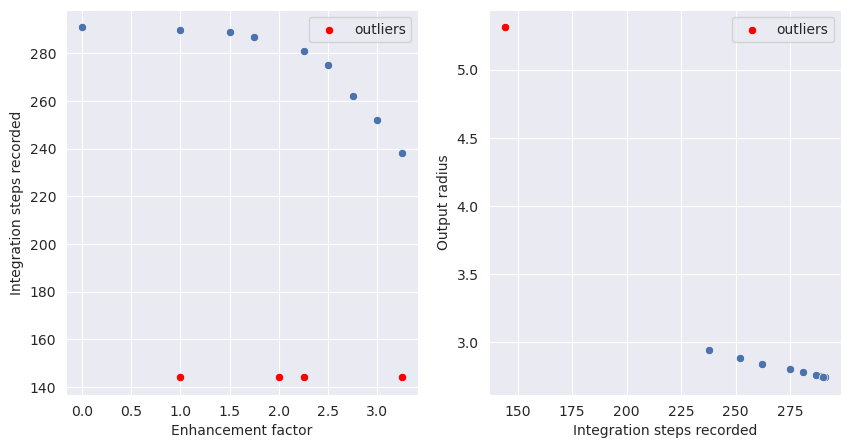

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axs = axes.flatten()
fac = [float(k.replace("-", ".")) for k in evodfs.keys()]
size = [len(df) for df in evodfs.values()]
radout = [df["Radius"][len(df)-1] for df in evodfs.values()]

fac_ = [float(k.replace("-", ".")) for k in evodfs2.keys()]
size_ = [len(df) for df in evodfs2.values()]
radout_ = [df["Radius"][len(df)-1] for df in evodfs2.values()]
sns.scatterplot(x=fac, y=size, ax=axs[0])
sns.scatterplot(x=fac_, y=size_, ax=axs[0], color='red', label='outliers')
sns.scatterplot(x=size, y=radout, ax=axs[1])
sns.scatterplot(x=size_, y=radout_, ax=axs[1], color='red', label='outliers')
axs[0].set_ylabel("Integration steps recorded")
axs[1].set_ylabel("Output radius")
axs[0].set_xlabel("Enhancement factor")
axs[1].set_xlabel("Integration steps recorded")

{'foo': 'bar'}